# YOLO26 nano — Ultralytics tasks with the Cyberwave Python SDK

Hands-on tour of **`cyberwave[ml]`**: load **YOLO26 *n*** checkpoints (**detection**, **segmentation**, **pose**, **classification**), call **`predict`**, inspect **`PredictionResult`**, and visualize outputs. Sections mirror common Ultralytics workflows but route loading and inference through **Cyberwave** so weights and caches follow the same conventions as Twin / cloud-backed flows.

---

### What this notebook demonstrates

| Area | What happens |
|:-----|:--------------|
| **Inference API** | `import cyberwave.models as cw_models` → **`cw_models.load(model_id)`** → **`model.predict(rgb_array, confidence=CONF)`**. Returns **`PredictionResult`** (iterable **`Detection`** rows: label, confidence, bbox; optional **keypoints** / mask references depending on task). **`pred.raw`** still holds **`ultralytics` `Results`** for task-specific extras (e.g. classification **`probs`**). |
| **RGB ↔ BGR** | Frames are **`numpy` RGB**. For overlays, **`Results.plot(..., img=...)`** expects a **BGR** base when you pass numpy; helpers below convert with **OpenCV** so **`matplotlib`** shows correct colors. |
| **Two sample images** | **`IMAGE_PATH`** — desk scene (detect / segment / classify). **`IMAGE_POSE_PATH`** — people scene for **pose** and for **cascaded** segmentation→pose overlays (`image_pose_rgb`). |
| **Cascade demo** | **`run_model_cascade([...], image_rgb)`** runs each model on the **same** frame, then **chains** Ultralytics plots in list order (e.g. masks then skeletons). |

---

### Cyberwave SDK (use this in your own code)

Copy the pattern from **`run_task`** / **`run_model_cascade`** internals:

```python
import cyberwave.models as cw_models
pred = cw_models.load("yolo26n.pt").predict(image_rgb_uint8, confidence=0.25)
```

Prefer **`PredictionResult.describe_detections_text()`** when your installed **`cyberwave`** exposes it for human-readable summaries; this notebook additionally prints **`print_prediction_table`** for explicit column-style lines in the terminal.

---

### Notebook-only helpers (not part of the SDK)

Everything in the big **imports + definitions** cell exists **only for this Jupyter walkthrough**: printing tidy tables and drawing figures.

| Helper | Role |
|:-------|:-----|
| **`load_image`**, **`show_image_rgb`** | Load PNG → RGB ndarray; matplotlib axis styling. |
| **`print_prediction_table`** | Prints **`PredictionResult`** rows to stdout (SDK types; notebook formatting only). |
| **`print_raw_classification`**, **`_as_int_list`**, **`_as_float_list`** | Read **`pred.raw[0].probs`** and print classification top‑5 (classification has no **`Detection`** rows). |
| **`plot_ultralytics_result`** | **`Results.plot(pil=True)`** + **`matplotlib`** figure for a **single** model. |
| **`plot_prediction_cascade`** | Chains **`plot`** across several **`pred.raw[0]`** results on successive BGR copies (overlay demo). |
| **`run_task`** | Glue: **`load`** → **`predict`** → **`print_prediction_table`** → **`print_raw_classification`** → **`plot_ultralytics_result`**. |
| **`run_model_cascade`**, **`run_segmentation_then_pose_cascade`** | Glue for multi-model **`predict`** plus **`plot_prediction_cascade`**. **`run_segmentation_then_pose_cascade`** is a thin preset over **`run_model_cascade`**. |

---

### Setup notes

Run the **pip** cell for **`cyberwave[ml]`**, **matplotlib**, **Pillow**, **numpy**, **`opencv-python-headless`**. The **credential** cell sets **`CYBERWAVE_API_KEY`** from **`~/.cyberwave/credentials.json`** (same idea as **`cyberwave login`**). **YOLO26** weights download on first **`load`**; keep **`ultralytics`** current via **`cyberwave[ml]`** dependency pins so **`yolo26n*.pt`** resolves.


In [ ]:
%pip install -q "cyberwave[ml]" matplotlib pillow requests numpy opencv-python-headless


In [2]:
# --- Local PNG paths (same folder as this notebook) ---
IMAGE_PATH = "engineer-desk.png"
IMAGE_POSE_PATH = "engineers-humans.png"
CONF = 0.25  # confidence threshold passed to Ultralytics


Then let's grep the CYBERWAVE_API_KEY if you already logged in with the cyberwave-cli `cyberwave login --token YOUR_TOKEN`

In [ ]:
import json
from pathlib import Path

path = Path("~/.cyberwave/credentials.json").expanduser()
cw_credentials = json.loads(open(path).read())
cw_api_key = cw_credentials["token"]
# Suppress output of this cell
%env CYBERWAVE_API_KEY=$cw_api_key

Or just set the API_KEY directly

In [ ]:
%env CYBERWAVE_API_KEY=YOUR_TOKEN

In [4]:
from __future__ import annotations

import textwrap
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import cyberwave.models as cw_models
from cyberwave.models.types import PredictionResult

%matplotlib inline


# Notebook-local only: matplotlib/stdout helpers below — not Cyberwave APIs.
# SDK usage: cw_models.load(...).predict(...); types: PredictionResult / Detection.

def load_image(path: str) -> np.ndarray:
    """RGB uint8 image (H, W, 3) for Ultralytics + matplotlib."""
    pil = Image.open(path).convert("RGB")
    return np.asarray(pil, dtype=np.uint8)


def show_image_rgb(ax, arr: np.ndarray) -> None:
    ax.imshow(arr)
    ax.axis("off")


def print_prediction_table(title: str, pred: PredictionResult) -> None:
    print(f"\n=== {title} — PredictionResult ({len(pred)} detection row(s)) ===")
    if not pred:
        print("(empty — see raw Ultralytics section for classification)")
        return
    for i, d in enumerate(pred):
        parts = [
            f"[{i}] {d.label!r}",
            f"conf={d.confidence:.3f}",
            f"bbox=({d.bbox.x1:.1f},{d.bbox.y1:.1f})-({d.bbox.x2:.1f},{d.bbox.y2:.1f})",
        ]
        if d.keypoints is not None:
            parts.append(f"keypoints shape={getattr(np.asarray(d.keypoints), 'shape', '?')}")
        if d.mask is not None:
            parts.append("mask=<array>")
        print("  " + " ".join(parts))


def _as_int_list(x) -> list[int]:
    if hasattr(x, "detach"):
        x = x.detach()
    if hasattr(x, "cpu"):
        x = x.cpu()
    if hasattr(x, "numpy"):
        x = x.numpy()
    return [int(v) for v in np.asarray(x).ravel()]


def _as_float_list(x) -> list[float]:
    if hasattr(x, "detach"):
        x = x.detach()
    if hasattr(x, "cpu"):
        x = x.cpu()
    if hasattr(x, "numpy"):
        x = x.numpy()
    return [float(v) for v in np.asarray(x, dtype=np.float64).ravel()]


def print_raw_classification(pred: PredictionResult) -> None:
    if pred.raw is None or len(pred.raw) == 0:
        return
    r0 = pred.raw[0]
    probs = getattr(r0, "probs", None)
    if probs is None:
        return
    names = r0.names
    print("\n--- Raw Ultralytics: classification top-5 ---")
    top5_idx = _as_int_list(probs.top5)
    top5_conf = _as_float_list(probs.top5conf)
    for rank, (idx, cf) in enumerate(zip(top5_idx, top5_conf), start=1):
        label = names[idx] if names else str(idx)
        print(f"  {rank}. {label!r}  {cf:.4f}")


def plot_ultralytics_result(pred: PredictionResult, title: str, *, orig_rgb: np.ndarray | None = None) -> None:
    """RGB for matplotlib: Ultralytics expects a BGR base image when drawing on RGB numpy captures."""
    if pred.raw is None or len(pred.raw) == 0:
        print("No raw results to plot")
        return
    r0 = pred.raw[0]
    plot_kw = {}
    try:
        import cv2
        if orig_rgb is not None:
            plot_kw["img"] = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR)
    except ImportError:
        pass
    plotted = r0.plot(pil=True, **plot_kw)
    if hasattr(plotted, "convert"):
        rgb = np.asarray(plotted.convert("RGB"))
    else:
        rgb = np.asarray(plotted)[..., ::-1]
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    show_image_rgb(ax, rgb)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_prediction_cascade(
    preds: Sequence[PredictionResult],
    plot_title: str,
    *,
    orig_rgb: np.ndarray,
    figsize: tuple[float, float] = (11, 11),
) -> None:
    """Apply each Ultralytics ``Results.plot`` on the painted output of the previous step (BGR via OpenCV)."""
    if not preds:
        print("plot_prediction_cascade: empty preds")
        return
    try:
        import cv2
    except ImportError:
        print(
            "OpenCV (cv2) not found. Re-run the first cell (installs opencv-python-headless) or: pip install opencv-python-headless",
            flush=True,
        )
        return
    current_bgr = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR).copy()
    final_pil = None
    for i, pred in enumerate(preds):
        if pred.raw is None or len(pred.raw) == 0:
            print(f"No raw Ultralytics batch at cascade step {i}; stopping plot chain")
            return
        final_pil = pred.raw[0].plot(pil=True, img=current_bgr)
        current_bgr = cv2.cvtColor(np.asarray(final_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    if final_pil is None:
        return
    rgb = np.asarray(final_pil.convert("RGB"))
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    show_image_rgb(ax, rgb)
    ax.set_title(plot_title)
    plt.tight_layout()
    plt.show()


def run_model_cascade(
    model_ids: Sequence[str],
    image_rgb: np.ndarray,
    *,
    plot_title: str | None = None,
    blurb: str | None = None,
) -> None:
    """Run each checkpoint on the same frame (order = overlay order), print tables, then one cascaded figure."""
    ids = tuple(model_ids)
    if not ids:
        print("run_model_cascade: pass at least one model id")
        return
    title = plot_title or "Cascaded: " + " → ".join(ids)
    print("\n" + "=" * 72)
    print(title)
    if blurb:
        print(textwrap.fill(blurb, 72))
    preds: list[PredictionResult] = []
    for mid in ids:
        preds.append(cw_models.load(mid).predict(image_rgb, confidence=CONF))
    for mid, pred in zip(ids, preds, strict=True):
        print_prediction_table(f"Branch — {mid}", pred)
        print_raw_classification(pred)
    plot_prediction_cascade(preds, title, orig_rgb=image_rgb)


def run_segmentation_then_pose_cascade(image_rgb: np.ndarray) -> None:
    """Convenience: seg masks then pose on ``image_rgb`` (same as two-entry ``run_model_cascade``)."""
    run_model_cascade(
        ["yolo26n-seg.pt", "yolo26n-pose.pt"],
        image_rgb,
        plot_title="Cascaded: segmentation (YOLO26n-seg) then pose (YOLO26n-pose)",
        blurb="Two forwards on the same RGB frame; plot order stacks Ultralytics overlays (masks then pose).",
    )


def run_task(title: str, model_id: str, image_rgb: np.ndarray) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("Model:", model_id)
    print(textwrap.fill("First load downloads weights into ~/.cyberwave/models (or CYBERWAVE_MODEL_DIR).", 72))
    model = cw_models.load(model_id)
    pred = model.predict(image_rgb, confidence=CONF)
    print_prediction_table(title, pred)
    print_raw_classification(pred)
    plot_ultralytics_result(pred, title, orig_rgb=image_rgb)


Loaded engineer-desk.png (1024, 1536, 3) uint8
Loaded engineers-humans.png (1122, 1402, 3) uint8


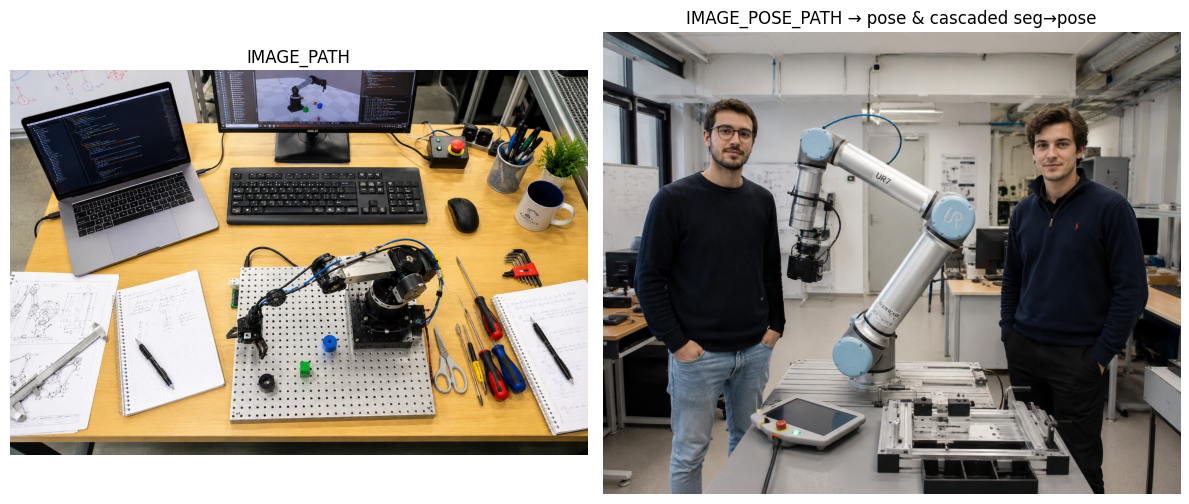

In [5]:
image_rgb = load_image(IMAGE_PATH)
image_pose_rgb = load_image(IMAGE_POSE_PATH)
print("Loaded", IMAGE_PATH, image_rgb.shape, image_rgb.dtype)
print("Loaded", IMAGE_POSE_PATH, image_pose_rgb.shape, image_pose_rgb.dtype)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
show_image_rgb(axes[0], image_rgb)
axes[0].set_title("IMAGE_PATH")
show_image_rgb(axes[1], image_pose_rgb)
axes[1].set_title("IMAGE_POSE_PATH → pose & cascaded seg→pose")
plt.tight_layout()
plt.show()


## Object detection — `yolo26n.pt`



YOLO26n detection
Model: yolo26n.pt
First load downloads weights into ~/.cyberwave/models (or
CYBERWAVE_MODEL_DIR).

=== YOLO26n detection — PredictionResult (9 detection row(s)) ===
  [0] 'laptop' conf=0.971 bbox=(28.0,28.8)-(556.1,553.3)
  [1] 'cup' conf=0.929 bbox=(1339.9,296.3)-(1500.0,431.2)
  [2] 'keyboard' conf=0.924 bbox=(576.9,254.0)-(1112.1,415.3)
  [3] 'mouse' conf=0.902 bbox=(1160.3,338.4)-(1246.3,434.6)
  [4] 'tv' conf=0.764 bbox=(538.8,0.0)-(1084.9,171.2)
  [5] 'potted plant' conf=0.533 bbox=(1402.8,157.0)-(1536.0,372.6)
  [6] 'book' conf=0.420 bbox=(280.9,531.3)-(575.5,924.4)
  [7] 'keyboard' conf=0.286 bbox=(162.6,274.7)-(488.4,446.0)
  [8] 'book' conf=0.254 bbox=(0.3,534.7)-(293.7,976.0)


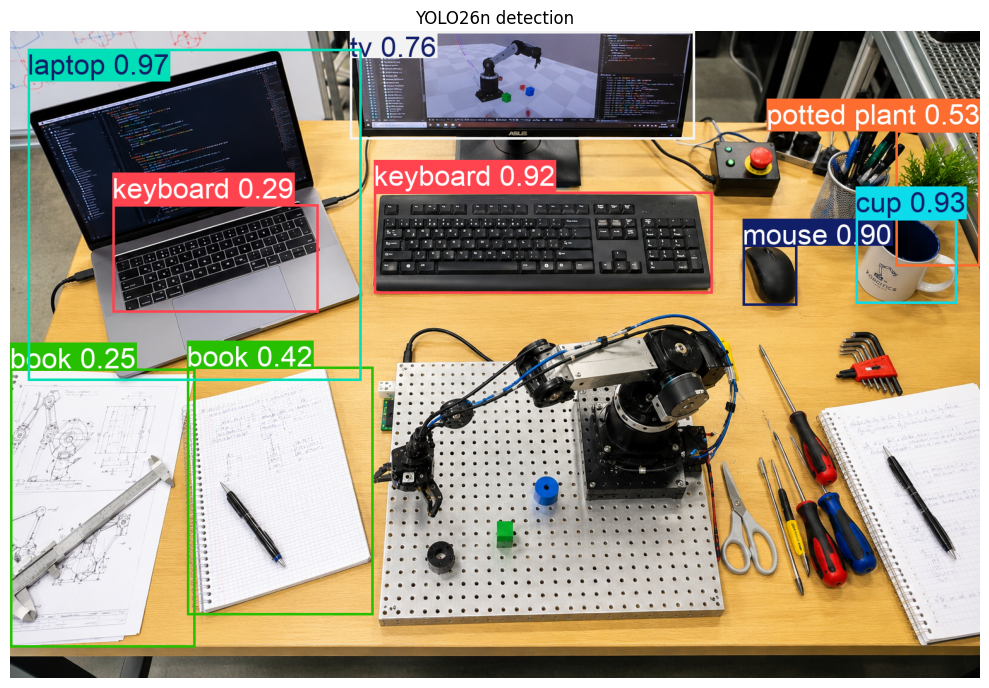

In [6]:
run_task("YOLO26n detection", "yolo26n.pt", image_rgb)


## Instance segmentation — `yolo26n-seg.pt`

`PredictionResult` carries **boxes** (and pose fields when relevant). **Mask tensors** stay on the raw `Results` object; the plotted image shows Ultralytics-drawn masks.


YOLO26n segmentation
Model: yolo26n-seg.pt
First load downloads weights into ~/.cyberwave/models (or
CYBERWAVE_MODEL_DIR).

=== YOLO26n segmentation — PredictionResult (6 detection row(s)) ===
  [0] 'keyboard' conf=0.954 bbox=(577.0,255.6)-(1111.4,413.9) mask=<array>
  [1] 'laptop' conf=0.952 bbox=(28.4,31.2)-(558.7,550.5) mask=<array>
  [2] 'mouse' conf=0.902 bbox=(1160.4,339.7)-(1245.7,434.0) mask=<array>
  [3] 'cup' conf=0.893 bbox=(1340.6,292.5)-(1502.7,431.6) mask=<array>
  [4] 'tv' conf=0.602 bbox=(538.8,1.5)-(1082.0,171.8) mask=<array>
  [5] 'book' conf=0.297 bbox=(278.7,532.7)-(576.4,928.2) mask=<array>


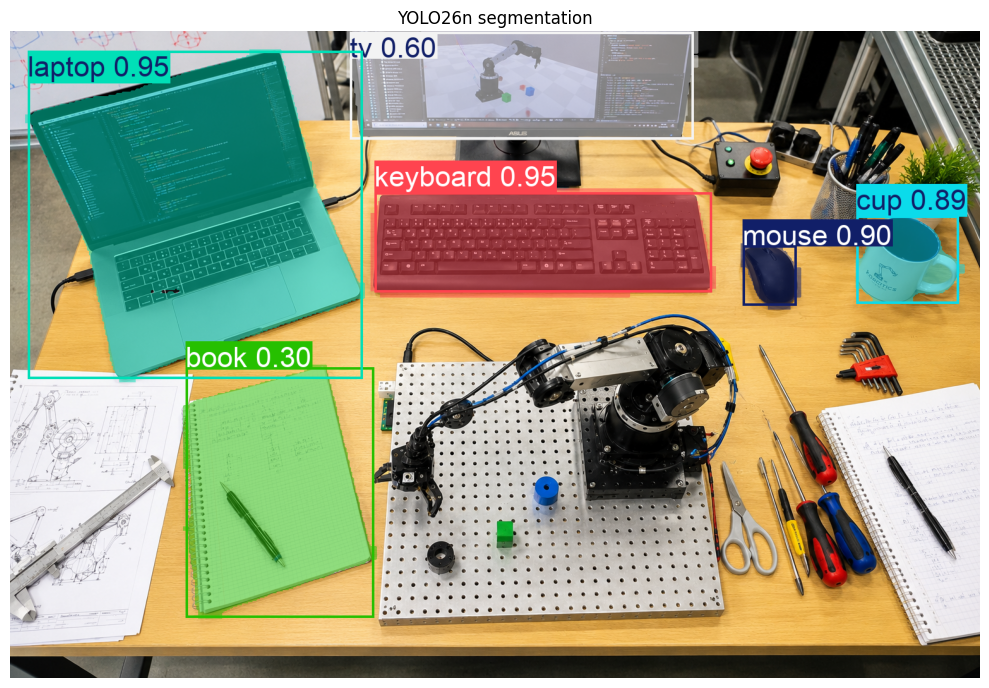

In [7]:
run_task("YOLO26n segmentation", "yolo26n-seg.pt", image_rgb)


## Pose — `yolo26n-pose.pt`

Each `Detection` includes **`keypoints`** (pixel coordinates, COCO layout). This section uses **`IMAGE_POSE_PATH`** (`image_pose_rgb`), not `IMAGE_PATH`.



YOLO26n pose
Model: yolo26n-pose.pt
First load downloads weights into ~/.cyberwave/models (or
CYBERWAVE_MODEL_DIR).

=== YOLO26n pose — PredictionResult (2 detection row(s)) ===
  [0] 'person' conf=0.951 bbox=(74.1,162.2)-(444.1,1122.0) keypoints shape=(17, 3)
  [1] 'person' conf=0.925 bbox=(958.8,182.0)-(1327.5,1120.4) keypoints shape=(17, 3)


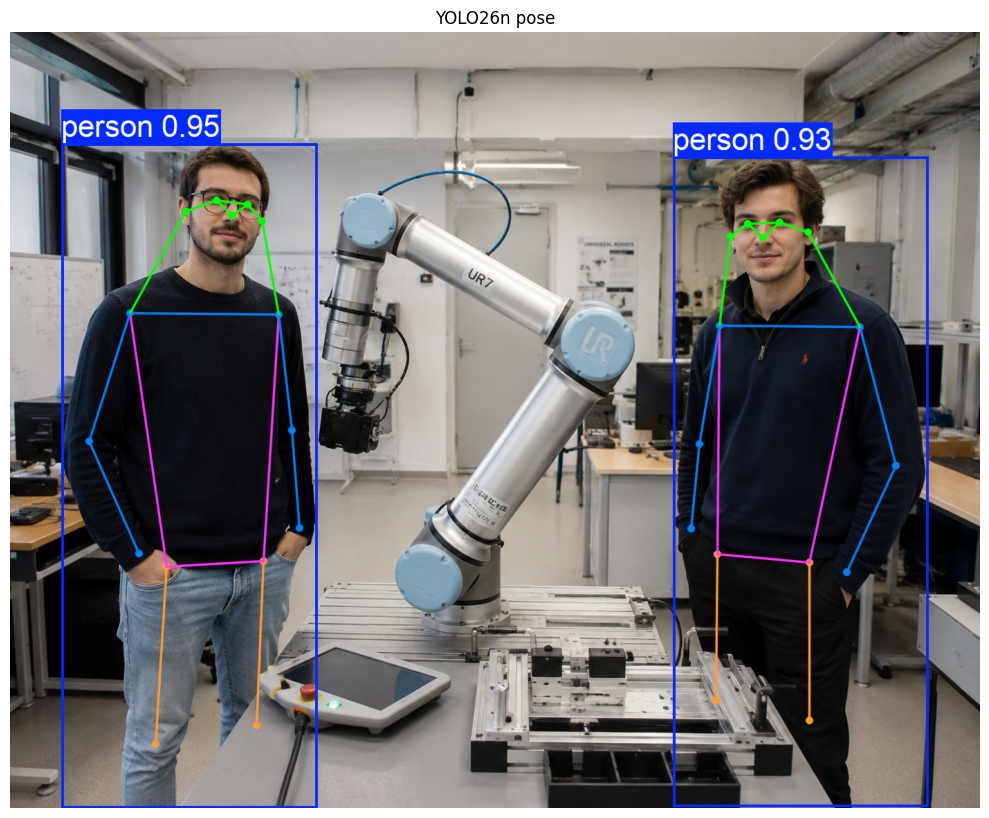

In [8]:
run_task("YOLO26n pose", "yolo26n-pose.pt", image_pose_rgb)


## Cascaded overlays — list of models

**SDK-native approach** — `cw.models.load([...])` returns a `CascadeModel` that runs every model on the same frame and collects results in a `CascadePredictionResult` keyed by model display name.

| API | What it does |
|:----|:-------------|
| `cw.models.list(filters=["edge", "image"])` | Filter catalog entries by shorthand strings (ANDed). |
| `cw.models.load([m1, m2, ...], store_input=True)` | Build a `CascadeModel`; set `store_input=True` to enable `draw_on_top()` without passing an image. |
| `cascade.predict(image)` | Run all models; returns `CascadePredictionResult`. |
| `pred[m.name]` | Access a single model's `PredictionResult` by display name. |
| `pred.draw_on_top()` | PIL image — all predictions overlaid on the stored input. |
| `pred.draw()` | PIL image — all predictions on a black canvas (same size). |
| `pred.describe()` | Human-readable summary (useful in notebook output cells). |

The first cell below uses the **SDK cascade API** directly.  The second cell uses the **notebook helper** `run_model_cascade()` (still works for raw string IDs and chains Ultralytics overlays).

**Requires:** `opencv-python-headless` (first install cell) for the legacy helper only.


[yolo26n-seg.pt] 4 detection(s)
    [0] 'person' conf=0.945 bbox=(960.6,175.6)-(1323.5,1121.1) mask(shape=(512, 640))
    [1] 'person' conf=0.940 bbox=(74.7,162.5)-(443.7,1117.3) mask(shape=(512, 640))
    [2] 'laptop' conf=0.288 bbox=(374.2,887.0)-(635.2,1012.0) mask(shape=(512, 640))
    [3] 'book' conf=0.275 bbox=(374.2,887.0)-(635.2,1012.0) mask(shape=(512, 640))
[yolo26n-pose.pt] 2 detection(s)
    [0] 'person' conf=0.951 bbox=(74.1,162.2)-(444.1,1122.0) keypoints(n=17, visible=15)
    [1] 'person' conf=0.925 bbox=(958.8,182.0)-(1327.5,1120.4) keypoints(n=17, visible=15)


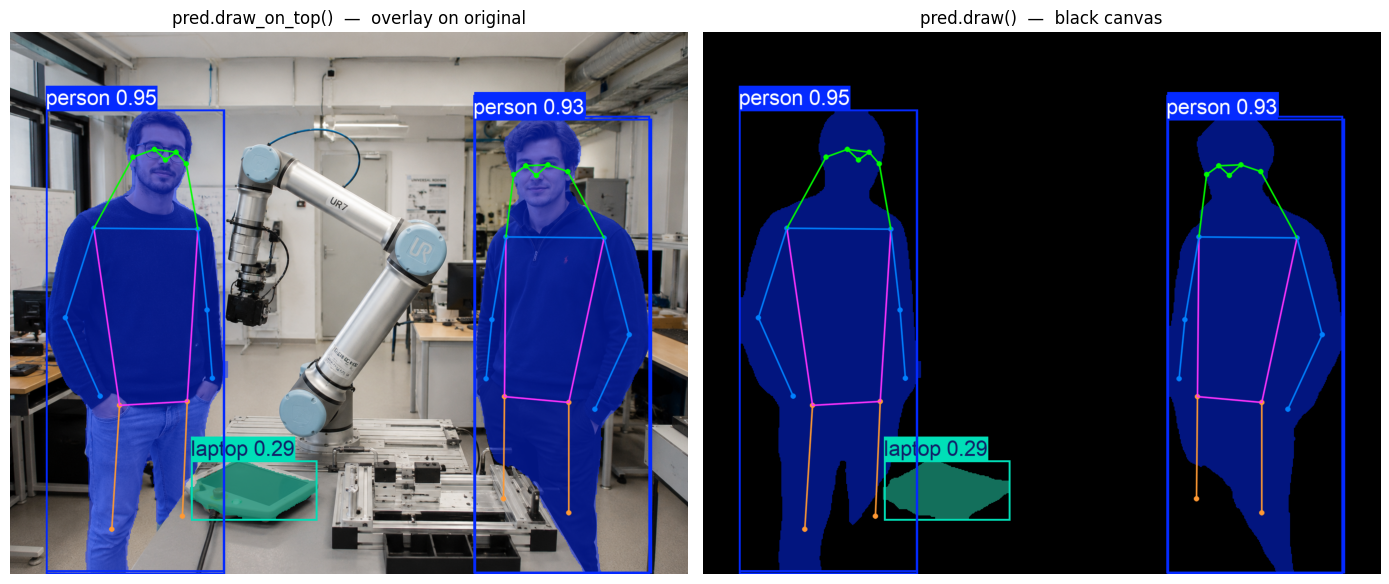

In [9]:
# ---------------------------------------------------------------------------
# SDK cascade — cw.models.load([entry1, entry2], store_input=True)
# ---------------------------------------------------------------------------
# Build the cascade from raw string IDs (same IDs as the notebook above).
# When models are fetched from the catalog you can pass MLModelSchema entries
# directly and the display name is taken from m.name automatically:
#
#   edge_models = cw.models.list(filters=["edge", "image"])
#   cascade = cw.models.load([edge_models[0], edge_models[1]], store_input=True)
#
# Here we use raw string IDs for simplicity (no catalog connection required).

import cyberwave.models as cw_models  # module-level load() uses the default client

cascade = cw_models.load(
    ["yolo26n-seg.pt", "yolo26n-pose.pt"],
    store_input=True,  # store the input frame so draw_on_top() works without args
)

cascade_pred = cascade.predict(image_pose_rgb, confidence=CONF)

# --- Inspect individual results ---
print(cascade_pred.describe())

# --- Draw on top of the original input (uses stored frame) ---
output_on_top = cascade_pred.draw_on_top()

# --- Draw on a black canvas ---
output_black = cascade_pred.draw()

# Show both side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(output_on_top)
axes[0].set_title("pred.draw_on_top()  —  overlay on original")
axes[0].axis("off")
axes[1].imshow(output_black)
axes[1].set_title("pred.draw()  —  black canvas")
axes[1].axis("off")
plt.tight_layout()
plt.show()



Cascaded: yolo26n-seg.pt → yolo26n-pose.pt
Two forwards; overlay order matches the list (seg then pose).

=== Branch — yolo26n-seg.pt — PredictionResult (4 detection row(s)) ===
  [0] 'person' conf=0.945 bbox=(960.6,175.6)-(1323.5,1121.1) mask=<array>
  [1] 'person' conf=0.940 bbox=(74.7,162.5)-(443.7,1117.3) mask=<array>
  [2] 'laptop' conf=0.288 bbox=(374.2,887.0)-(635.2,1012.0) mask=<array>
  [3] 'book' conf=0.275 bbox=(374.2,887.0)-(635.2,1012.0) mask=<array>

=== Branch — yolo26n-pose.pt — PredictionResult (2 detection row(s)) ===
  [0] 'person' conf=0.951 bbox=(74.1,162.2)-(444.1,1122.0) keypoints shape=(17, 3)
  [1] 'person' conf=0.925 bbox=(958.8,182.0)-(1327.5,1120.4) keypoints shape=(17, 3)


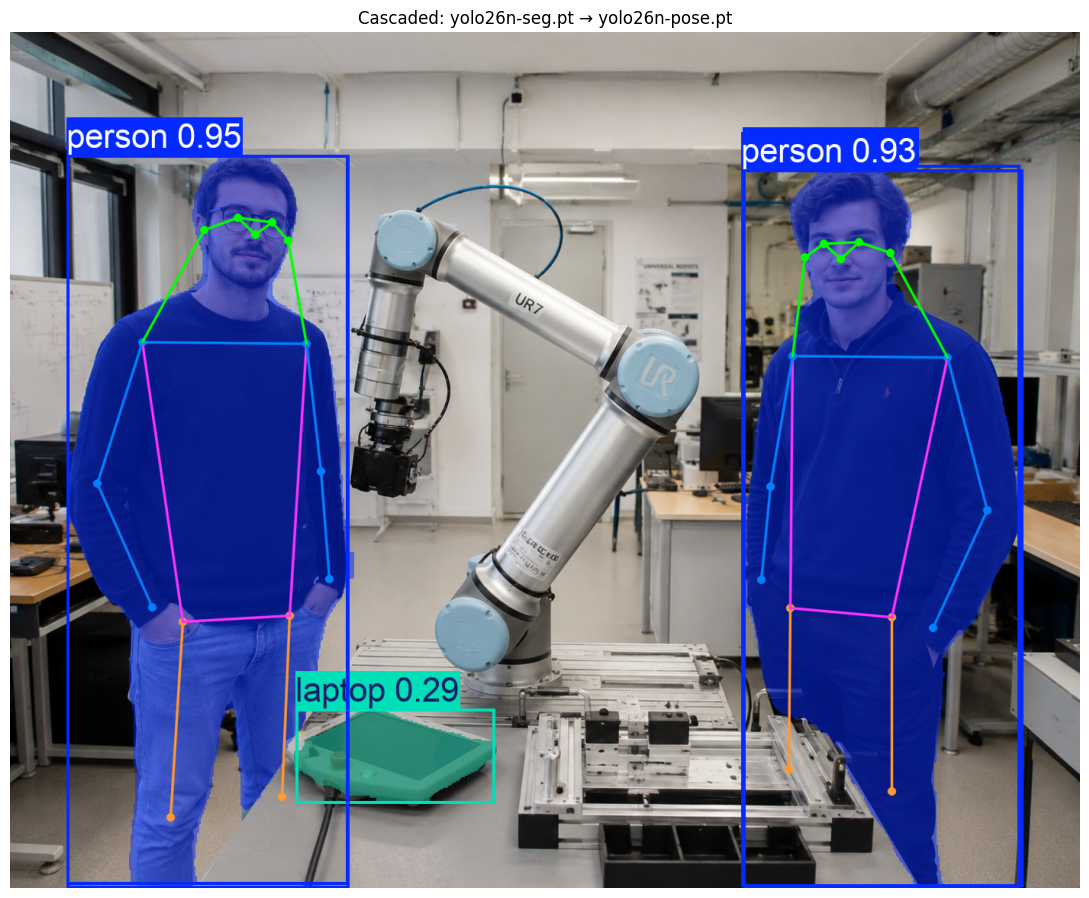

In [10]:
run_model_cascade(
    ["yolo26n-seg.pt", "yolo26n-pose.pt"],
    image_pose_rgb,
    blurb="Two forwards; overlay order matches the list (seg then pose).",
)


## Classification — `yolo26n-cls.pt`

Classification outputs **probabilities**, not boxes — **`PredictionResult` is empty**. Top-5 labels come from **`pred.raw[0].probs`** and the plot shows Ultralytics’ classification viz.


YOLO26n classification
Model: yolo26n-cls.pt
First load downloads weights into ~/.cyberwave/models (or
CYBERWAVE_MODEL_DIR).

=== YOLO26n classification — PredictionResult (5 detection row(s)) ===

--- Raw Ultralytics: classification top-5 ---
  1. 'desk'  0.3580
  2. 'mouse'  0.1174
  3. 'joystick'  0.1134
  4. 'desktop_computer'  0.0827
  5. 'modem'  0.0666


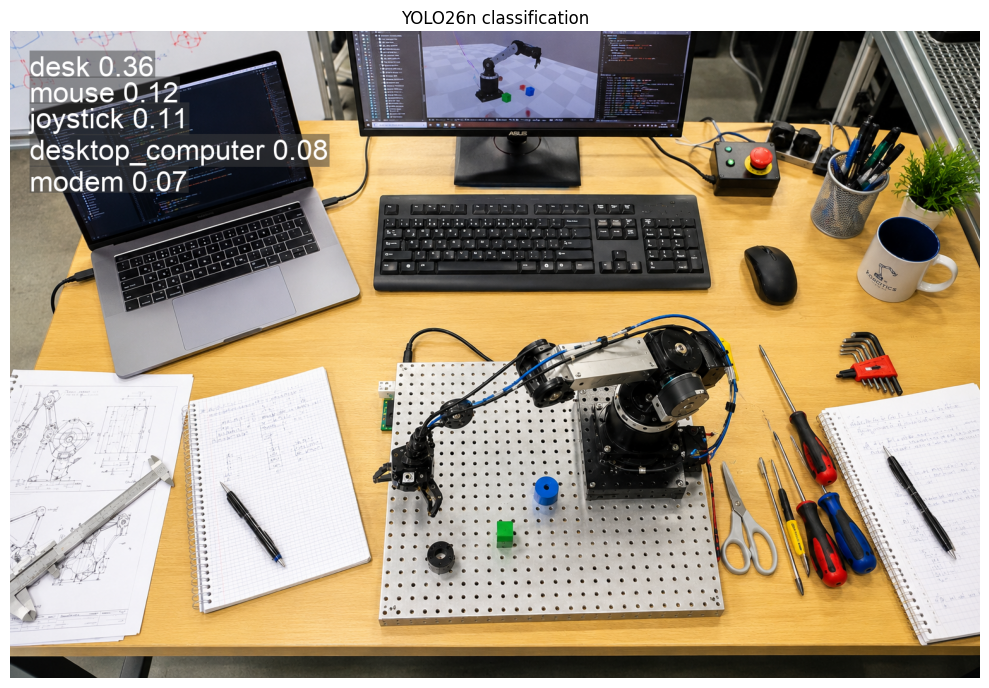

In [11]:
run_task("YOLO26n classification", "yolo26n-cls.pt", image_rgb)
